<a href="https://colab.research.google.com/github/Emmanuelkiptim/Logistic-Regression-in-Predicting-Employee-Retention/blob/main/Logistic_Regression_assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Download employee retention dataset from here: https://www.kaggle.com/giripujar/hr-analytics.

1. Now do some exploratory data analysis to figure out which variables have direct and clear impact on employee retention (i.e. whether they leave the company or continue to work)
2. Plot bar charts showing impact of employee salaries on retention
3. Plot bar charts showing corelation between department and employee retention
4. Now build logistic regression model using variables that were narrowed down in step 1
5. Measure the accuracy of the model

## Import Libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import linear_model
from sklearn import model_selection


Load and eyeball the dataset

In [8]:
df=pd.read_csv('https://raw.githubusercontent.com/codebasics/py/refs/heads/master/ML/7_logistic_reg/Exercise/HR_comma_sep.csv')
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [9]:
##Average numbers for all columns
df.groupby(df.left).mean(numeric_only=True)


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years
left,,,,,,,
0,0.666810,0.715473,3.786664,199.060203,3.380032,0.175009,0.026251
1,0.440098,0.718113,3.855503,207.419210,3.876505,0.047326,0.005321


satisfaction below 0.44 average, promotion average at 0.005, monthly hours > @207

<Axes: xlabel='salary', ylabel='count'>

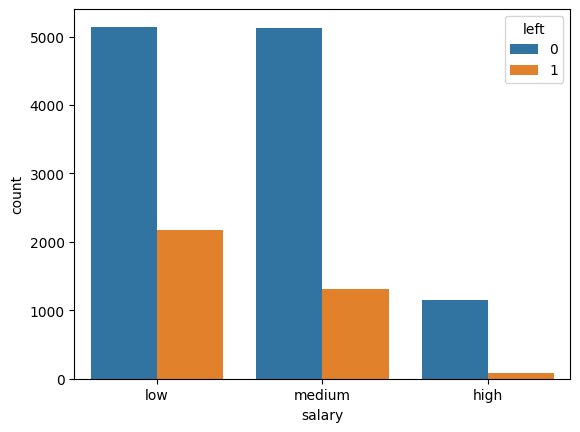

In [10]:
## Plot bar charts showing impact of employee salaries on retention
sns.countplot(data=df,x='salary',hue='left')

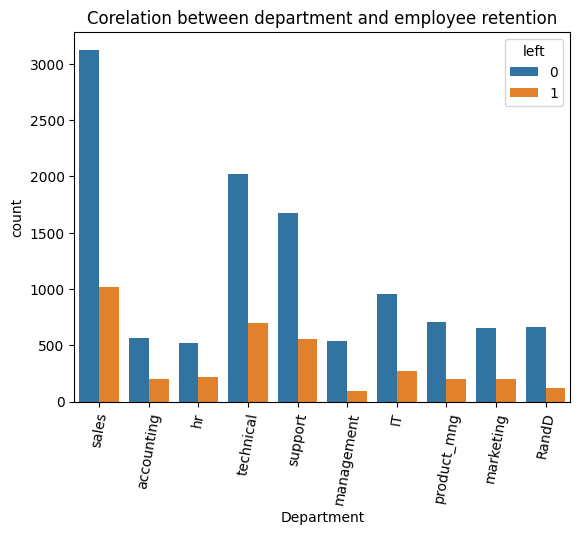

In [11]:
##Plot bar charts showing corelation between department and employee retention
sns.countplot(data=df,x='Department',hue='left')
plt.xticks(rotation=80)
plt.title('Corelation between department and employee retention')
plt.show()

In [12]:
## Now build logistic regression model using variables that were narrowed down in step 1
## identify x and y
Y=df.left
Y
X=df[['satisfaction_level','average_montly_hours','promotion_last_5years','salary']]
## dummy the salary column
Xdummies=pd.get_dummies(X['salary'])
FinalXdummies=Xdummies.drop('medium',axis='columns')
X=pd.concat([X,FinalXdummies],axis='columns')
X.drop('salary',axis='columns',inplace=True)
X
## split the data
X_train,X_test,Y_train,Y_test=model_selection.train_test_split(X,Y,test_size=0.1)
Y_train
## Build the model
model=linear_model.LogisticRegression()
## Train the model
model.fit(X_train,Y_train)
## Evaluate the model
ModelScore=model.score(X_test,Y_test)
print(f"The accuracy of the model is: {ModelScore*100} %")
## save the model
import joblib
joblib.dump(model,'Retention Prediction Model')



The accuracy of the model is: 79.13333333333334 %


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


['Retention Prediction Model']